<a href="https://colab.research.google.com/github/priyankachougala/Mall_Customers1/blob/main/Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (3).csv


In [108]:
import pandas as pd
import numpy as np
df = pd.read_csv('Mall_Customers.csv')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [85]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [86]:
df.columns =(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[()$]","",regex =True)
    .str.replace("_","_")
    .str.replace(" ","_")
)

In [87]:
df.columns

Index(['customerid', 'gender', 'age', 'annual_income_k',
       'spending_score_1-100'],
      dtype='object')

In [88]:
df.describe()

,customerid,age,annual_income_k,spending_score_1-100
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [89]:
#selecting feature

x = df[['annual_income_k','spending_score_1-100']]
x.head()

,annual_income_k,spending_score_1-100
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [90]:
#since there is no label , the model can use only is distance between points

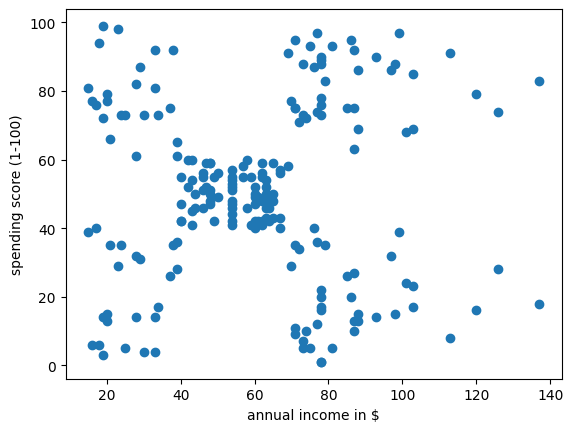

In [91]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x["annual_income_k"],x['spending_score_1-100'])
plt.xlabel("annual income in $")
plt.ylabel("spending score (1-100)")
plt.show()

In [92]:
#k means clustering
#k means tries to group pointer so the points in the
#same group are close to each other
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, random_state=42)
labels = kmeans.fit_predict(x)


# n_cluster ,divide the customer into 5 groups
# fit(x) - look at all data pionts in x,place
#5 random centroids
#assigns each point to center of assigned points in
#iteration
#repeats untill stable
#for each data point returns which cluster it belongs to
#represents them with numeric value

In [93]:
labels[:10]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2], dtype=int32)

In [94]:
df["cluster"] = labels
df.head()

,customerid,gender,age,annual_income_k,spending_score_1-100,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


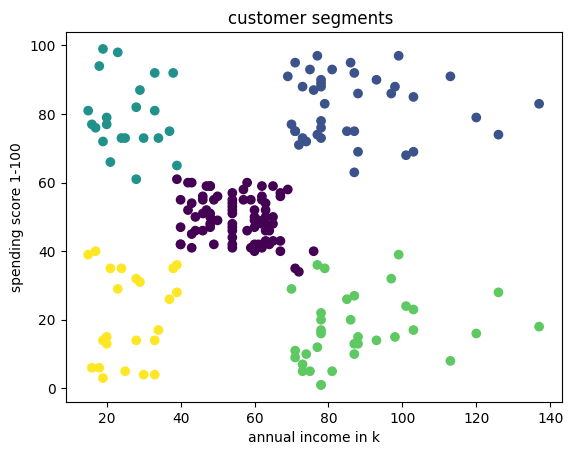

In [95]:
#visualize clusters
plt.scatter(
    x['annual_income_k'],
    x['spending_score_1-100'],
    c=labels
    )
plt.xlabel('annual income in k')
plt.ylabel('spending score 1-100')
plt.title('customer segments ')
plt.show()

In [96]:
# elbow methods
# it helps to find how  many groups to use
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)


  # wcss-within cluster sum of squares
  # lower wcss-tightly clusters
  # higher wcss-less dense clusters

  # we will store this for each kmeans each loop new model different number of clusters

  # in each loop k increases ,wcss decreases and improvement slows down after certain point

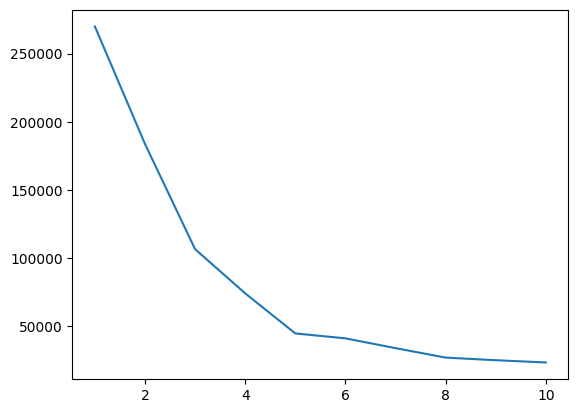

In [97]:
plt.plot(range(1,11),wcss)

In [98]:
kmeans=KMeans(n_clusters=10,random_state=42)
labels = kmeans.fit_predict(x)

In [99]:
labels[:10]

array([6, 3, 4, 3, 6, 3, 4, 3, 4, 3], dtype=int32)

In [100]:
df["cluster"]=labels
df.head()

,customerid,gender,age,annual_income_k,spending_score_1-100,cluster
0,1,Male,19,15,39,6
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,6


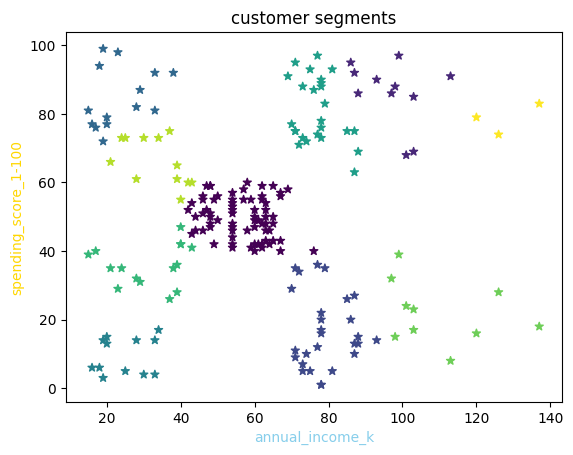

In [101]:
# #visualize clusters
plt.scatter(
    x['annual_income_k'],
    x['spending_score_1-100'],
    marker="*",
    c=labels
)

plt.xlabel('annual_income_k',color="skyblue")
plt.ylabel('spending_score_1-100',color="gold")
plt.title('customer segments')
plt.show()

In [102]:
# applying PCA here
# Principal Compound Analysis

from  sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# components = 2 - reducing data 2 dimensions,
# information preserved mostly

# PCA are used when data has many feature ,
# so pca compores information then we visualize it
# pca does not create clusters,it helps us see them

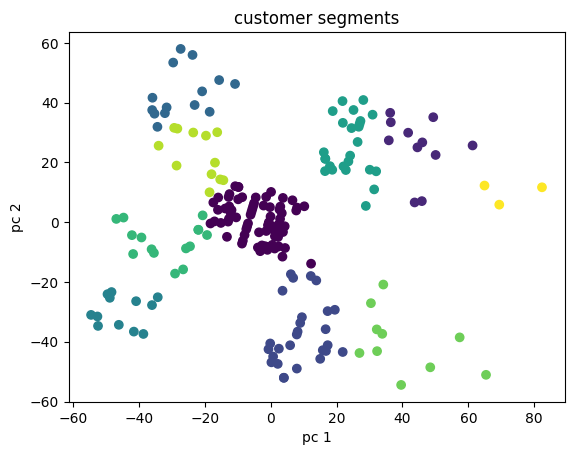

In [103]:
#visualize clusters using PCA

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=df['cluster']

)

plt.xlabel('pc 1')
plt.ylabel('pc 2')
plt.title('customer segments')
plt.show()

In [104]:
df.groupby('cluster')[['annual_income_k','spending_score_1-100']].mean()

,annual_income_k,spending_score_1-100
cluster,,
0,56.464789,49.774648
1,97.090909,86.090909
2,79.000000,16.592593
3,23.428571,84.785714
4,24.583333,9.583333
5,76.960000,80.800000
6,31.533333,35.866667
7,109.700000,22.000000
8,33.500000,66.250000


In [105]:
df['segment']= df['cluster'].map({
    0: 'mid income - mid speed',
    1: 'high income - high speed',
    2: 'low  income - high spped',
    3: 'high  income - low speed',
    4: 'low   income - low spped'
    })

In [106]:
df.head()

,customerid,gender,age,annual_income_k,spending_score_1-100,cluster,segment
0,1,Male,19,15,39,6,NaN
1,2,Male,21,15,81,3,high income - low speed
2,3,Female,20,16,6,4,low income - low spped
3,4,Female,23,16,77,3,high income - low speed
4,5,Female,31,17,40,6,NaN


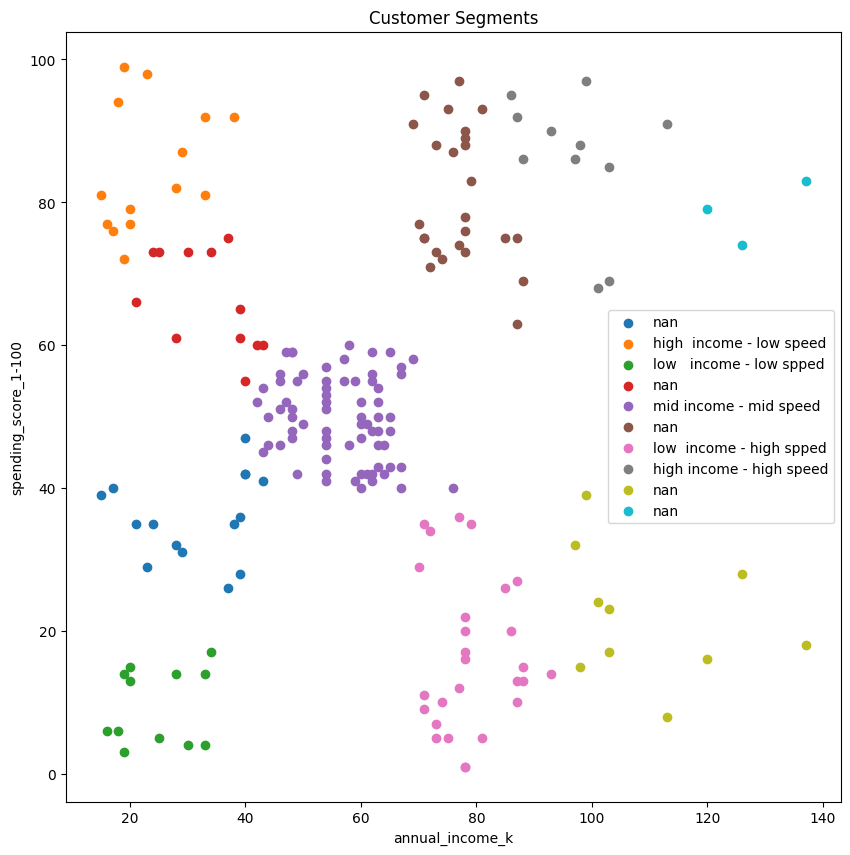

In [107]:
plt.figure(figsize=(10,10))
for segment_name,cluster_id in df[['segment','cluster']].drop_duplicates().itertuples(index=False):
    subset = df[df['cluster'] == cluster_id]
    plt.scatter(
        subset['annual_income_k'],
        subset['spending_score_1-100'],
        label=segment_name
    )
plt.xlabel('annual_income_k')
plt.ylabel('spending_score_1-100')
plt.legend()
plt.title('Customer Segments')
plt.show()